## Setup and Data Loading

In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
warnings.filterwarnings("ignore")

In [3]:
from src.config import (
    KEEP_COLS, SUBJECTS, GENDER_MAP, IMMIG_MAP, LOC_MAP, SCHLTYPE_MAP,
    PERCENTILES_COARSE, PERCENTILES_FINE, PALETTE,
    COUNTRY_COLORS, YEAR_COLORS, MIN_GROUP_N,
)

from src.data_loader import load_sample_csv
from src.pisa_stats import (
    weighted_mean_pv,
    weighted_percentiles_pv,
    compute_group_percentiles,
    compute_escs_quartile_percentiles,
    get_oecd_percentiles,
)

print("Imports done.")

Imports done.


In [4]:
# Global plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linewidth":   0.7,
    "font.family":      "sans-serif",
    "font.size":        11,
})

COUNTRIES   = ["CAN", "USA"]
PERCS       = PERCENTILES_COARSE   
PERCS_FINE  = PERCENTILES_FINE     
COLORS      = COUNTRY_COLORS       

CNT_LABELS  = {"CAN": "Canada", "USA": "United States"}

In [5]:
# Load data 
DATA_PATH = project_root / "data" / "raw" / "sampledat.csv"

df = load_sample_csv(str(DATA_PATH))
df = df[df["CNT"].isin(COUNTRIES)].copy()

print(f"Loaded: {df.shape[0]:,} students x {df.shape[1]} columns")
print(df["CNT"].value_counts().to_string())

Loaded: 27,625 students x 134 columns
CNT
CAN    23073
USA     4552


## Data Quality - Missing Data Audit

In [6]:
AUDIT_VARS = {
    "Gender (ST004D01T)":      "ST004D01T",
    "School funding (SCHLTYPE)": "SCHLTYPE",
    "SES index (ESCS)":        "ESCS",
    "School location":         "SC001Q01TA",
    "Home possessions":        "HOMEPOS",
    "Parental educ. (PAREDINT)":"PAREDINT",
    "Grade repetition (REPEAT)":"REPEAT",
    "Immigration (IMMIG)":     "IMMIG",
    "Late arrivals":           "ST062Q03TA",
    "School belonging":        "BELONG",
    "Parental occ. (HISEI)":   "HISEI",
    "Math motivation":         "MATHMOT",
}

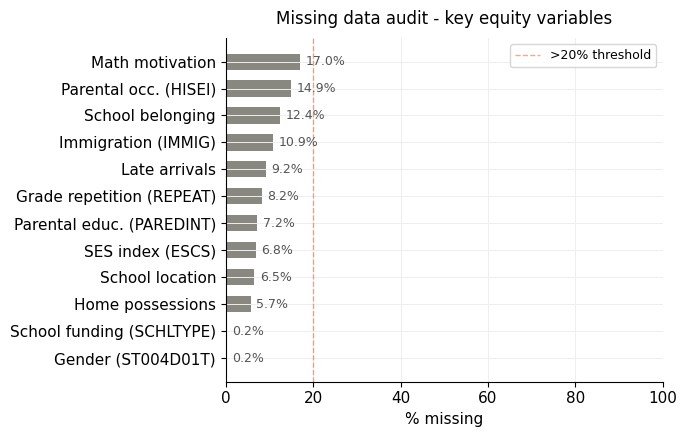

In [9]:
audit_rows = [
    {"Variable": label, "Missing (%)": round(df[col].isna().mean() * 100, 1)}
    for label, col in AUDIT_VARS.items()
    if col in df.columns
]
audit_df = pd.DataFrame(audit_rows).sort_values("Missing (%)")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#D85A30" if v > 20 else "#888780" for v in audit_df["Missing (%)"]]
bars = ax.barh(audit_df["Variable"], audit_df["Missing (%)"],
               color=colors, height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color="#555555")
ax.set_xlim(0, 100)
ax.set_xlabel("% missing")
ax.set_title("Missing data audit - key equity variables",
             fontsize=12, fontweight="500", pad=10)
ax.axvline(20, color="#D85A30", lw=1, ls="--", alpha=0.5, label=">20% threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## How do the two countries compare overall?

## 1. Score distributions across all three subjects

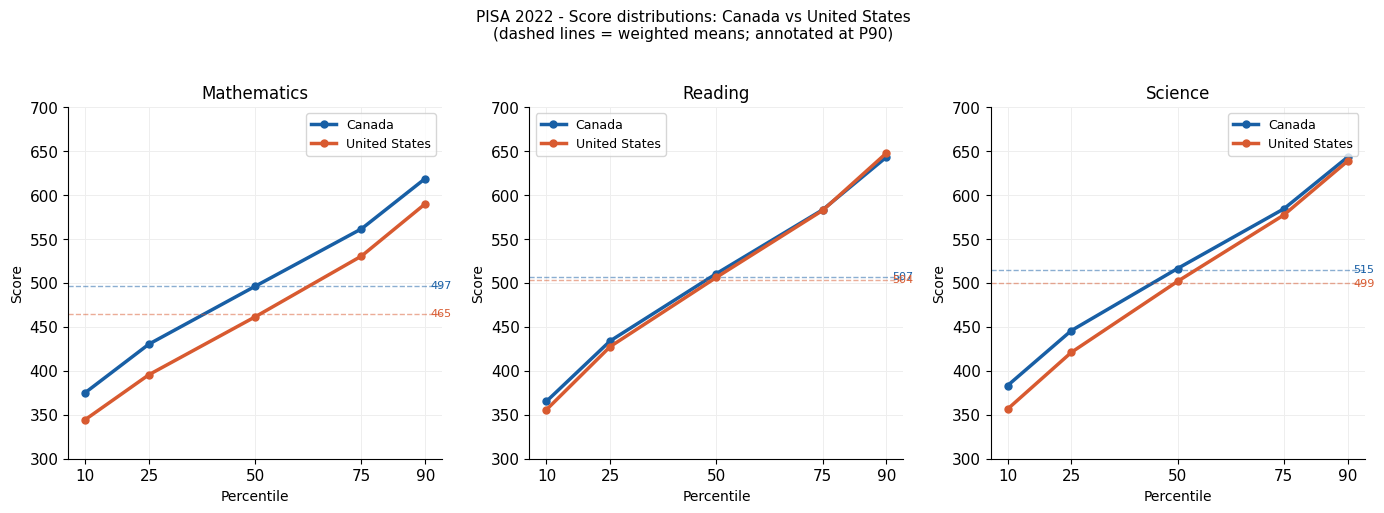

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    for cnt in COUNTRIES:
        subset     = df[df["CNT"] == cnt]
        pv_percs   = weighted_percentiles_pv(subset, subj, PERCS)
        mean_score = weighted_mean_pv(subset, subj)

        ax.plot(PERCS, pv_percs,
                color=COLORS[cnt], lw=2.5, marker="o", ms=5,
                label=CNT_LABELS[cnt])
        ax.axhline(mean_score, color=COLORS[cnt], lw=1, ls="--", alpha=0.5)

        # annotate mean on the right edge
        ax.annotate(f"{mean_score:.0f}",
                    xy=(PERCS[-1], mean_score),
                    xytext=(4, 0), textcoords="offset points",
                    color=COLORS[cnt], fontsize=8, va="center")

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    ax.set_xticks(PERCS)
    ax.set_ylim(300, 700)
    ax.legend(fontsize=9)

fig.suptitle(
    "PISA 2022 - Score distributions: Canada vs United States\n"
    "(dashed lines = weighted means; annotated at P90)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 2. P90-P10 spread by subject

In [11]:
# Build summary: mean, P10, P50, P90, spread 
rows = []
for cnt in COUNTRIES:
    subset = df[df["CNT"] == cnt]
    for subj, name in SUBJECTS.items():
        mean   = weighted_mean_pv(subset, subj)
        percs  = weighted_percentiles_pv(subset, subj, [10, 50, 90])
        rows.append({
            "Country": CNT_LABELS[cnt],
            "Subject": name,
            "Mean":    round(mean, 1),
            "P10":     round(percs[0], 1),
            "Median":  round(percs[1], 1),
            "P90":     round(percs[2], 1),
            "Spread (P90−P10)": round(percs[2] - percs[0], 1),
        })
summary = pd.DataFrame(rows)

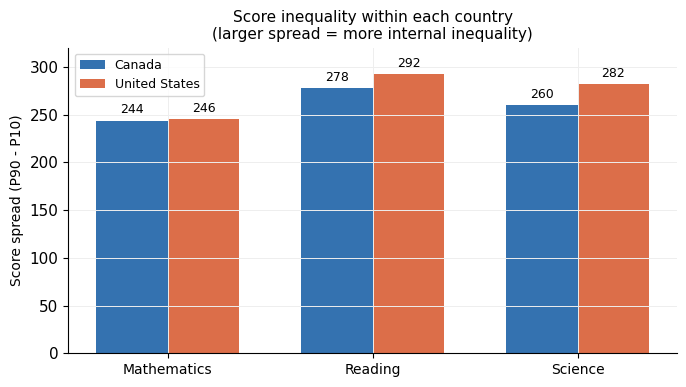


Summary table:
      Country     Subject  Mean   P10  Median   P90  Spread (P90−P10)
       Canada Mathematics 496.9 375.2   496.3 618.9             243.7
       Canada     Reading 507.1 365.3   510.7 643.2             278.0
       Canada     Science 515.0 383.3   516.5 643.2             259.9
United States Mathematics 464.9 344.5   461.5 590.1             245.6
United States     Reading 503.9 355.8   506.4 647.8             292.1
United States     Science 499.4 356.5   501.9 638.7             282.1


In [12]:
spread_pivot = summary.pivot(index="Subject", columns="Country",
                              values="Spread (P90−P10)")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(spread_pivot))
w = 0.35
for i, cnt in enumerate(COUNTRIES):
    label = CNT_LABELS[cnt]
    vals  = spread_pivot[label].values
    bars  = ax.bar(x + i * w, vals, w,
                   label=label, color=COLORS[cnt], alpha=0.88)
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

ax.set_xticks(x + w / 2)
ax.set_xticklabels(spread_pivot.index, fontsize=10)
ax.set_ylabel("Score spread (P90 - P10)", fontsize=10)
ax.set_ylim(0, 320)
ax.set_title("Score inequality within each country\n"
             "(larger spread = more internal inequality)",
             fontsize=11, fontweight="500")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nSummary table:")
print(summary.to_string(index=False))

## 3. Percentile gap plot

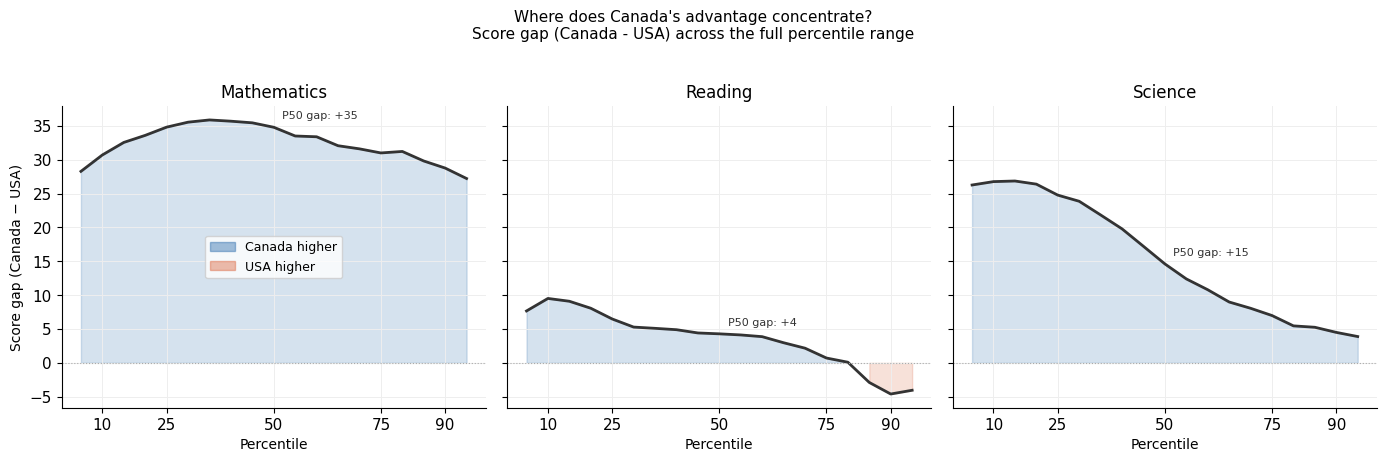

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (subj, name) in zip(axes, SUBJECTS.items()):
    can_percs = weighted_percentiles_pv(df[df["CNT"] == "CAN"], subj, PERCS_FINE)
    usa_percs = weighted_percentiles_pv(df[df["CNT"] == "USA"], subj, PERCS_FINE)
    gap       = can_percs - usa_percs

    # shade positive (CAN advantage) vs negative (USA advantage)
    ax.fill_between(PERCS_FINE, gap, 0,
                    where=(gap >= 0), alpha=0.18, color=COLORS["CAN"])
    ax.fill_between(PERCS_FINE, gap, 0,
                    where=(gap < 0),  alpha=0.18, color=COLORS["USA"])
    ax.plot(PERCS_FINE, gap, color="#333333", lw=2)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls=":")

    ax.set_title(name, fontsize=12, fontweight="500")
    ax.set_xlabel("Percentile", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Score gap (Canada − USA)", fontsize=10)
    ax.set_xticks([10, 25, 50, 75, 90])

    # Annotate at median
    mid_idx = PERCS_FINE.index(50)
    ax.annotate(f"P50 gap: {gap[mid_idx]:+.0f}",
                xy=(50, gap[mid_idx]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, color="#333333")

can_patch = mpatches.Patch(color=COLORS["CAN"], alpha=0.4, label="Canada higher")
usa_patch = mpatches.Patch(color=COLORS["USA"], alpha=0.4, label="USA higher")
axes[0].legend(handles=[can_patch, usa_patch], fontsize=9)

fig.suptitle(
    "Where does Canada's advantage concentrate?\n"
    "Score gap (Canada - USA) across the full percentile range",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()